# Water-limited regimes precede aerosol extreme events across the U.S. Southwest

## Raw MERRA-2 files were sliced to U.S. Southwest and converted from UTC to Mountain Time

This code reproduces Figures 3 and 4 from the paper

By: Juliana Mejia Sepulveda
email: julianamejia@arizona.edu


# 1. Libraries

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os

import scipy
from scipy import stats
from scipy.stats import spearmanr
from scipy.stats import pearsonr


import dask
import dask.array as da
import zipfile
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
from matplotlib.patches import FancyArrowPatch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# 2. Figure 3. TS, WS and Z500 Standardized Anomalies

## 2.1 Reading MERRA data (temperature, wind speed and specific humidity—later used to calculate vpd)

In [2]:
#====Directory====
directory = '/xdisk/sylvia/julianamejia/tmp_merra_slv'

In [3]:
#====Reading files====
ds_hourly_sw = []

# Loop through the files
for archivo in os.listdir(directory):
    if archivo.endswith('.nc4'):
        ruta_archivo = os.path.join(directory, archivo)
        ds_hourly = xr.open_dataset(ruta_archivo, engine="netcdf4")
        ds_hourly_sw.append(ds_hourly)


In [4]:
filtered = [ds for ds in ds_hourly_sw if 'PS' in ds.variables]

#====Concat files by time====
sw_data = xr.concat(filtered, dim='time', coords = 'minimal')
sw_data = sw_data.set_index(time="time")
sw_data = sw_data.sortby("time")
sw_data['time'] = pd.to_datetime(sw_data['time'].values)


In [5]:
#====Calculate hourly wind speed====
sw_data['WS'] = np.sqrt(sw_data['U10M']**2 + sw_data['V10M']**2)
sw_data['WS'].attrs['units'] = 'm/s'
sw_data['WS'].attrs['long_name'] = '10-meter Wind Speed'

### 2.1.1 Resampling to daily max

In [6]:
#====Resample data to daily maximum. U and V components will be used where WS where max====
# 1. Daily max for TS and WS
daily_max_ts = sw_data['TS'].groupby(sw_data['time'].dt.floor('D')).max('time')
daily_max_ws = sw_data['WS'].groupby(sw_data['time'].dt.floor('D')).max('time')

daily_max_ts = daily_max_ts.rename({'floor': 'time'})
daily_max_ws = daily_max_ws.rename({'floor': 'time'})

# 2. Group by day
daily_groups = sw_data.groupby(sw_data['time'].dt.floor('D'))

# 3. Loop over each group to find U and V at max WS
uv_list = []
dates = []

for date, day_data in daily_groups:
    idx = day_data['WS'].argmax(dim='time')
    uv_at_max = day_data.isel(time=idx)[['U10M', 'V10M']]
    uv_list.append(uv_at_max)
    dates.append(np.datetime64(date))

# 4. Combine U and V components into Dataset
for i in range(len(uv_list)):
    uv_list[i] = uv_list[i].reset_coords('time', drop=True) #Drop time first so we can concat by it later

uv_at_ws_max_daily = xr.concat(uv_list, dim='time')
uv_at_ws_max_daily['time'] = ('time', dates)
uv_at_ws_max_daily = uv_at_ws_max_daily.sortby('time')

# 5. Create final dataset with all variables
max_data = xr.Dataset({
    'TS_max': daily_max_ts,
    'WS_max': daily_max_ws,
    'U10M_at_WSmax': uv_at_ws_max_daily['U10M'],
    'V10M_at_WSmax': uv_at_ws_max_daily['V10M']
})


In [7]:
max_data['TS_max'] = max_data['TS_max'] - 273.15
max_data['TS_max'].attrs['units'] = '°C'

### 2.1.2 Computing the events standardized anomalies

In [8]:
# ============================================================
# Calculate standardized weekly anomalies for TS and WS
# ============================================================

lat_min, lat_max = 32, 40
lon_min, lon_max = -120, -108

figure3_events = [
    ("2017-08-23", "2017-08-30"),
    ("2020-09-01", "2020-09-07"),
    ("2021-06-08", "2021-06-16"),
]

threshold_sigma = 1
EPS = 1e-9

# Figure-specific name prevents later cells from overwriting these masks.
figure3_results = []
years_all = np.unique(max_data["time"].dt.year.values)

for start_str, end_str in figure3_events:
    start_dt = pd.to_datetime(start_str)
    end_dt = pd.to_datetime(end_str)
    event_year = start_dt.year

    target_start = start_dt.strftime("%m-%d")
    target_end = end_dt.strftime("%m-%d")

    # Event-week subset and means
    event_week = max_data.sel(time=slice(start_dt, end_dt))
    if event_week.time.size == 0:
        print(f"Skipping {start_dt.date()} to {end_dt.date()}: no event data")
        continue

    ts_event = event_week["TS_max"].mean("time", skipna=True)
    ws_event = event_week["WS_max"].mean("time", skipna=True)
    u_event = event_week["U10M_at_WSmax"].mean("time", skipna=True)
    v_event = event_week["V10M_at_WSmax"].mean("time", skipna=True)

    # Same calendar window in all other available years
    ts_weekly_means = []
    ws_weekly_means = []
    climatology_years = []

    for year in years_all:
        if year == event_year:
            continue

        clim_start = pd.Timestamp(f"{int(year)}-{target_start}")
        clim_end = pd.Timestamp(f"{int(year)}-{target_end}")
        clim_week = max_data.sel(time=slice(clim_start, clim_end))

        if clim_week.time.size == 0:
            continue

        ts_weekly_means.append(clim_week["TS_max"].mean("time", skipna=True))
        ws_weekly_means.append(clim_week["WS_max"].mean("time", skipna=True))
        climatology_years.append(int(year))

    if len(ts_weekly_means) < 2 or len(ws_weekly_means) < 2:
        print(f"Skipping {start_dt.date()} to {end_dt.date()}: insufficient climatology")
        continue

    year_index = pd.Index(climatology_years, name="year")
    ts_stack = xr.concat(ts_weekly_means, dim=year_index)
    ws_stack = xr.concat(ws_weekly_means, dim=year_index)

    ts_clim_mean = ts_stack.mean("year", skipna=True)
    ws_clim_mean = ws_stack.mean("year", skipna=True)
    ts_clim_std = ts_stack.std("year", skipna=True, ddof=1)
    ws_clim_std = ws_stack.std("year", skipna=True, ddof=1)

    ts_clim_std = xr.where(ts_clim_std < EPS, np.nan, ts_clim_std)
    ws_clim_std = xr.where(ws_clim_std < EPS, np.nan, ws_clim_std)

    ts_z = (ts_event - ts_clim_mean) / ts_clim_std
    ws_z = (ws_event - ws_clim_mean) / ws_clim_std
    ts_z.name = "TS_standardized_anomaly"
    ws_z.name = "WS_standardized_anomaly"

    # Hot-pixel mask reused by Figure 5
    mask_sigma = np.isfinite(ts_z) & (ts_z > threshold_sigma)

    # Percentage inside the southwest rectangle
    rect_mask = (
        (ts_z["lat"] >= lat_min)
        & (ts_z["lat"] <= lat_max)
        & (ts_z["lon"] >= lon_min)
        & (ts_z["lon"] <= lon_max)
    ).broadcast_like(ts_z)

    valid_rect = rect_mask & np.isfinite(ts_z)
    n_valid = int(valid_rect.sum().compute().item())

    if n_valid > 0:
        n_sigma = int((mask_sigma & valid_rect).sum().compute().item())
        pct_sigma = 100 * n_sigma / n_valid
    else:
        pct_sigma = np.nan

    figure3_results.append((
        ts_z.transpose("lat", "lon"),
        ws_z.transpose("lat", "lon"),
        u_event.transpose("lat", "lon"),
        v_event.transpose("lat", "lon"),
        mask_sigma.transpose("lat", "lon"),
        pct_sigma, ))

    print(
        f"{start_dt.date()} to {end_dt.date()}: "
        f"{pct_sigma:.2f}% of valid southwest pixels exceed +1σ")

print(f"\nFigure 3 results created for {len(figure3_results)} events.")

if len(figure3_results) != len(figure3_events):
    raise RuntimeError("Figure 3 results were not created for all three events.")


2017-08-23 to 2017-08-30: 64.12% of valid southwest pixels exceed +1σ
2020-09-01 to 2020-09-07: 89.41% of valid southwest pixels exceed +1σ
2021-06-08 to 2021-06-16: 57.06% of valid southwest pixels exceed +1σ

Figure 3 results created for 3 events.


## 2.2 Reading MERRA data (geopotential height)

In [9]:
#====Directory====
dir_geo = '/xdisk/sylvia/julianamejia/tmp_merra_geo_sw'

In [10]:
#====Reading files====
ds_geopotential_sw = []
file_names = []
errors = []


for archivo in os.listdir(dir_geo):
    if archivo.endswith('.nc4'):
        file_path = os.path.join(dir_geo, archivo)
        try:
            ds_geopotential = xr.open_dataset(file_path, engine="netcdf4")
            ds_geopotential_sw.append(ds_geopotential)
            file_names.append(archivo)
        except FileNotFoundError:
            errors.append(archivo)

In [11]:
#====Concat files by time====
geop_data = xr.concat(ds_geopotential_sw, dim='time', coords='minimal')
geop_data = geop_data.set_index(time='time')
geop_data = geop_data.sortby('time')

### 2.2.1 Resampling to daily max

In [12]:
#====Resample data to daily maximum. U and V components will be used where WS where max====
# 1. Select level closest to 500 hPa
lev_500 = geop_data.sel(lev=500, method='nearest')

# 2. Get daily max of H at 500 hPa
daily_max_H = lev_500['H'].groupby(lev_500['time'].dt.floor('D')).max('time')

# 3. Group full 500 hPa-level data by day
daily_groups = lev_500.groupby(lev_500['time'].dt.floor('D'))

# 4. Loop to find T, U, V at time of max H
uvt_list = []
dates = []

for date, day_data in daily_groups:
    idx = day_data['H'].argmax(dim='time')
    selected = day_data.isel(time=idx)[['T', 'U', 'V']]
    selected = selected.reset_coords('time', drop=True)
    
    # Compute WS = sqrt(U² + V²)
    ws = np.sqrt(selected['U']**2 + selected['V']**2)
    selected['WS'] = ws
    
    uvt_list.append(selected)
    dates.append(np.datetime64(date))

# 5. Concatenate results
uvt_at_Hmax = xr.concat(uvt_list, dim='time')
uvt_at_Hmax['time'] = ('time', dates)
uvt_at_Hmax = uvt_at_Hmax.sortby('time')

#6. Rename H_max dimension to match the other variables
daily_max_H = daily_max_H.rename({'floor': 'time'})

# 7. Final dataset
max_geo500 = xr.Dataset({
    'H_max': daily_max_H,
    'T_at_Hmax': uvt_at_Hmax['T'],
    'U_at_Hmax': uvt_at_Hmax['U'],
    'V_at_Hmax': uvt_at_Hmax['V'],
    'WS_at_Hmax': uvt_at_Hmax['WS']})

#max_geo500

In [13]:
# === Calculate standardized weekly anomalies for each event ===
events = [
    ("2017-08-23", "2017-08-30"),
    ("2020-09-01", "2020-09-07"),
    ("2021-06-08", "2021-06-16"),]

std_anomaly_results_H500 = []
wind_vectors_H500 = []

EPS = 1e-6
years_all = np.unique(max_geo500['time'].dt.year.values)

for start_str, end_str in events:
    start_dt = pd.to_datetime(start_str)
    end_dt   = pd.to_datetime(end_str)
    event_year = start_dt.year

    target_start = start_dt.strftime("%m-%d")
    target_end   = end_dt.strftime("%m-%d")

    # --- Event-week mean ---
    event_week = max_geo500.sel(time=slice(start_dt, end_dt))
    if event_week.time.size == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no data")
        continue

    h_event_mean = event_week['H_max'].mean(dim='time', skipna=True)

    # actual event-week wind vectors
    u_mean = event_week['U_at_Hmax'].mean(dim='time', skipna=True).transpose('lat', 'lon')
    v_mean = event_week['V_at_Hmax'].mean(dim='time', skipna=True).transpose('lat', 'lon')

    # --- One weekly mean per non-event year ---
    weekly_means = []

    for yr in years_all:
        if yr == event_year:
            continue

        start_y = pd.Timestamp(f"{yr}-{target_start}")
        end_y   = pd.Timestamp(f"{yr}-{target_end}")

        week_y = max_geo500.sel(time=slice(start_y, end_y))

        if week_y.time.size > 0:
            weekly_means.append(week_y['H_max'].mean(dim='time', skipna=True))

    if len(weekly_means) == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no climatology weeks")
        continue

    clim_stack = xr.concat(weekly_means, dim='year')
    clim_years = [yr for yr in years_all if yr != event_year][:len(weekly_means)]
    clim_stack = clim_stack.assign_coords(year=("year", clim_years))

    # --- Climatological mean and std of weekly means ---
    h_clim = clim_stack.mean(dim='year', skipna=True)
    h_std  = clim_stack.std(dim='year', ddof=1, skipna=True)
    h_std  = xr.where(h_std < EPS, np.nan, h_std)

    # --- Standardized weekly anomaly ---
    h_z = ((h_event_mean - h_clim) / h_std).transpose('lat', 'lon')
    std_anomaly_results_H500.append(h_z)

    wind_vectors_H500.append((u_mean, v_mean))

## 2.3. Figure 3

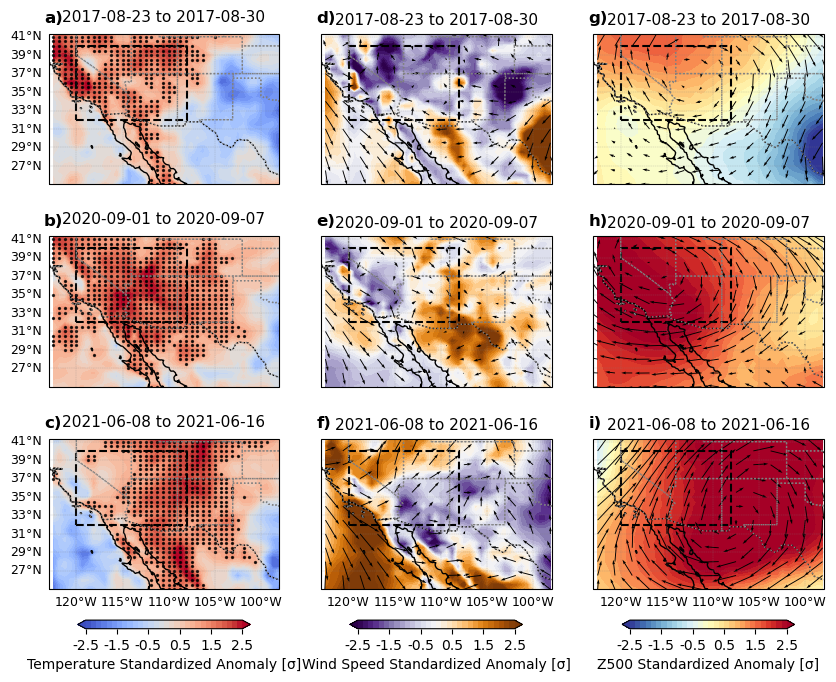

In [14]:
# =========================================================
# Shared settings
# =========================================================
titles = [
    "2017-08-23 to 2017-08-30",
    "2020-09-01 to 2020-09-07",
    "2021-06-08 to 2021-06-16"]

ts_labels = ['a', 'b', 'c']
ws_labels = ['d', 'e', 'f']
h_labels  = ['g', 'h', 'i']

extent_ts_ws = [-123, -98, 25, 41]

lat_min, lat_max = 32, 40
lon_min, lon_max = -120, -108

# =========================================================
# Fixed symmetric ranges
# =========================================================
vabs_ts = 2.5
vabs_ws = 2.5
vabs_h  = 2.5

ts_norm = TwoSlopeNorm(vcenter=0, vmin=-vabs_ts, vmax=vabs_ts)
ws_norm = TwoSlopeNorm(vcenter=0, vmin=-vabs_ws, vmax=vabs_ws)
h_norm  = TwoSlopeNorm(vcenter=0, vmin=-vabs_h,  vmax=vabs_h)

# =========================================================
# Create figure
# =========================================================
fig, axes = plt.subplots( 3, 3,figsize=(10, 8),subplot_kw={'projection': ccrs.PlateCarree()})

fig.subplots_adjust(wspace=0.18, hspace=0.18)

pcm_ts0 = None
pcm_ws0 = None
pcm_h0  = None

for i in range(3):

    ts, ws, u, v, mask_sigma, pct_sigma = figure3_results[i]

    h_z = std_anomaly_results_H500[i]
    u_h, v_h = wind_vectors_H500[i]

    # Coordinate grids
    lon2d_ts, lat2d_ts = np.meshgrid(ts['lon'], ts['lat'])
    lon2d_h,  lat2d_h  = np.meshgrid(h_z['lon'], h_z['lat'])

    # Column 1: Temperature
    ax_ts = axes[i, 0]

    ax_ts._autoscaleXon = False
    ax_ts._autoscaleYon = False
    ax_ts.set_extent(extent_ts_ws)

    pcm_ts = ax_ts.contourf(lon2d_ts,lat2d_ts,ts, cmap='coolwarm', norm=ts_norm,
        levels=np.linspace(-vabs_ts, vabs_ts, 31), transform=ccrs.PlateCarree(), extend='both')

    if i == 0:
        pcm_ts0 = pcm_ts

    # T>1std
    y_mask, x_mask = np.where(mask_sigma.values & np.isfinite(ts.values))

    if y_mask.size > 0:
        ax_ts.scatter(lon2d_ts[y_mask, x_mask],lat2d_ts[y_mask, x_mask],s=1.8,
            c='black',alpha=0.8,transform=ccrs.PlateCarree())

    # Southwest rectangle
    ax_ts.add_patch(Rectangle((lon_min, lat_min),lon_max - lon_min,lat_max - lat_min,linewidth=1.5,
        edgecolor='black',facecolor='none',linestyle='--',transform=ccrs.PlateCarree()))

    ax_ts.set_title(titles[i], fontsize=11)

    ax_ts.add_feature(cf.COASTLINE)
    ax_ts.add_feature(cf.BORDERS, linestyle=':')
    ax_ts.add_feature(cf.STATES, linestyle=':', edgecolor='gray')

    # Grid and labels
    gl = ax_ts.gridlines(draw_labels=True,linewidth=0.3,color='gray',
        alpha=0.5,linestyle='--')

    gl.top_labels = False
    gl.right_labels = False

    # Longitude labels
    if i < 2:
        gl.bottom_labels = False
    else:
        gl.bottom_labels = True

    # Latitude labels
    gl.left_labels = True

    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    gl.xlocator = mticker.FixedLocator(np.arange(-125, -97, 5))
    gl.ylocator = mticker.FixedLocator(np.arange(25, 42, 2))

    ax_ts.text(-0.02,1.15,f"{ts_labels[i]})",transform=ax_ts.transAxes,fontsize=12,
        fontweight='bold',va='top', ha='left')

    # Column 2: Wind Speed
    ax_ws = axes[i, 1]

    ax_ws._autoscaleXon = False
    ax_ws._autoscaleYon = False
    ax_ws.set_extent(extent_ts_ws)

    pcm_ws = ax_ws.contourf(lon2d_ts,lat2d_ts,ws,cmap='PuOr_r',norm=ws_norm,
        levels=np.linspace(-vabs_ws, vabs_ws, 31),transform=ccrs.PlateCarree(),extend='both')

    if i == 0:
        pcm_ws0 = pcm_ws

    step = 3

    ax_ws.quiver(lon2d_ts[::step, ::step],lat2d_ts[::step, ::step], np.nan_to_num(u.values)[::step, ::step],
        np.nan_to_num(v.values)[::step, ::step],color='black',scale=100,width=0.004,transform=ccrs.PlateCarree() )

    # Southwest
    ax_ws.add_patch(Rectangle((lon_min, lat_min),lon_max - lon_min,lat_max - lat_min,
        linewidth=1.5,edgecolor='black',facecolor='none',linestyle='--', transform=ccrs.PlateCarree()))

    ax_ws.set_title(titles[i], fontsize=11)

    ax_ws.add_feature(cf.COASTLINE)
    ax_ws.add_feature(cf.BORDERS, linestyle=':')
    ax_ws.add_feature(cf.STATES, linestyle=':', edgecolor='gray')

    # Grid and labels
    gl = ax_ws.gridlines(draw_labels=True,linewidth=0.3, color='gray',alpha=0.5,linestyle='--')

    gl.top_labels = False
    gl.right_labels = False

    # longitude labels
    if i < 2:
        gl.bottom_labels = False
    else:
        gl.bottom_labels = True

    # latitude labels
    gl.left_labels = False

    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    gl.xlocator = mticker.FixedLocator(np.arange(-125, -97, 5))
    gl.ylocator = mticker.FixedLocator(np.arange(25, 42, 2))

    ax_ws.text( -0.02,1.15,f"{ws_labels[i]})",transform=ax_ws.transAxes,fontsize=12,
        fontweight='bold',va='top',ha='left')

    # Column 3: Z500
    ax_h = axes[i, 2]

    ax_h._autoscaleXon = False
    ax_h._autoscaleYon = False
    ax_h.set_extent(extent_ts_ws)

    pcm_h = ax_h.contourf(lon2d_h,lat2d_h,h_z,cmap='RdYlBu_r',norm=h_norm,
        levels=np.linspace(-vabs_h, vabs_h, 31),transform=ccrs.PlateCarree(),extend='both')

    if i == 0:
        pcm_h0 = pcm_h

    u_vals_h = np.nan_to_num(getattr(u_h, "values", u_h))
    v_vals_h = np.nan_to_num(getattr(v_h, "values", v_h))

    ax_h.quiver(lon2d_h[::step, ::step],lat2d_h[::step, ::step],u_vals_h[::step, ::step],
        v_vals_h[::step, ::step],color='black',scale=100,width=0.004, transform=ccrs.PlateCarree())

    # Southwest
    ax_h.add_patch(Rectangle((lon_min, lat_min),lon_max - lon_min,lat_max - lat_min,
        linewidth=1.5,edgecolor='black',facecolor='none',linestyle='--',transform=ccrs.PlateCarree()))

    ax_h.set_title(titles[i], fontsize=11)

    ax_h.add_feature(cf.COASTLINE)
    ax_h.add_feature(cf.BORDERS, linestyle=':')
    ax_h.add_feature(cf.STATES, linestyle=':', edgecolor='gray')

    # Grid and labels
    gl = ax_h.gridlines(draw_labels=True,linewidth=0.3,color='gray',
        alpha=0.5,linestyle='--')

    gl.top_labels = False
    gl.right_labels = False

    #  longitude labels
    if i < 2:
        gl.bottom_labels = False
    else:
        gl.bottom_labels = True

    # latitude labels
    gl.left_labels = False

    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    gl.xlocator = mticker.FixedLocator(np.arange(-125, -97, 5))
    gl.ylocator = mticker.FixedLocator(np.arange(25, 42, 2))

    ax_h.text(-0.02,1.15,f"{h_labels[i]})",transform=ax_h.transAxes,
        fontsize=12,fontweight='bold',va='top',ha='left')

# Colorbars
cbar_ts = fig.colorbar(pcm_ts0,ax=axes[:, 0].tolist(),orientation='horizontal',
    fraction=0.014, pad=0.05)

cbar_ts.set_label('Temperature Standardized Anomaly [σ]')
cbar_ts.ax.tick_params(labelsize=10)

ticks_ts = np.arange(-vabs_ts, vabs_ts + 1.0, 1.0)
cbar_ts.set_ticks(ticks_ts)
cbar_ts.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

cbar_ws = fig.colorbar(pcm_ws0,ax=axes[:, 1].tolist(),orientation='horizontal',
    fraction=0.014,pad=0.05)

cbar_ws.set_label('Wind Speed Standardized Anomaly [σ]')
cbar_ws.ax.tick_params(labelsize=10)

ticks_ws = np.arange(-vabs_ws, vabs_ws + 1.0, 1.0)
cbar_ws.set_ticks(ticks_ws)
cbar_ws.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

cbar_h = fig.colorbar(pcm_h0,ax=axes[:, 2].tolist(),
    orientation='horizontal',fraction=0.014,pad=0.05)

cbar_h.set_label('Z500 Standardized Anomaly [σ]')
cbar_h.ax.tick_params(labelsize=10)

ticks_h = np.arange(-vabs_h, vabs_h + 1.0, 1.0)
cbar_h.set_ticks(ticks_h)
cbar_h.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.savefig('Figure3_Temperature_Wind_Speed_Z500_Standardized_Anomalies.png',dpi=200, bbox_inches='tight')

plt.show()


In [15]:
print(f"\nPercentage of pixels > {threshold_sigma}σ inside southwest boundaries:\n")

for i, (_, _, _, _, _, pct_sigma) in enumerate(figure3_results):
    print(f"{titles[i]}: {pct_sigma:.2f}%")



Percentage of pixels > 1σ inside southwest boundaries:

2017-08-23 to 2017-08-30: 64.12%
2020-09-01 to 2020-09-07: 89.41%
2021-06-08 to 2021-06-16: 57.06%


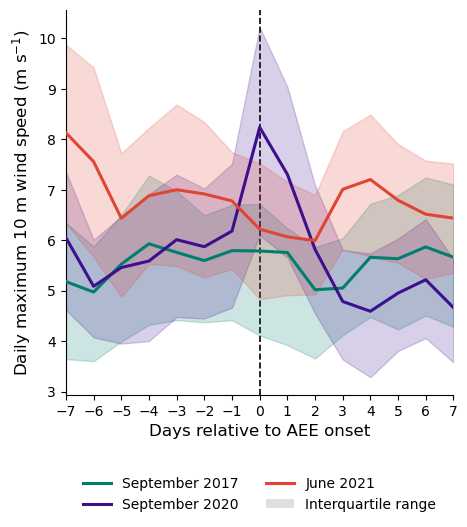

In [16]:
# ============================================================
# Extended Data Figure 9:
# Evolution of surface winds before/during AEEs
# ============================================================

extent_ts_ws = [-123, -98, 25, 41]  # lon_min, lon_max, lat_min, lat_max

events = {
    "September 2017": "2017-09-01",
    "September 2020": "2020-09-08",
    "June 2021": "2021-06-17"}

window_days = 7
offsets = np.arange(-window_days, window_days + 1)  

# study region
ws = max_data["WS_max"].sel(lon=slice(extent_ts_ws[0], extent_ts_ws[1]),lat=slice(extent_ts_ws[2], extent_ts_ws[3]))


# Regional mean + IQR per day, for each event window
wind_timeseries_results = {}

for label, onset_str in events.items():

    onset = pd.Timestamp(onset_str)
    dates = [onset + pd.Timedelta(days=int(d)) for d in offsets]

    ws_window = ws.sel(time=dates)  # (time, lat, lon)

    mean_ts = ws_window.mean(dim=["lat", "lon"], skipna=True)
    q25_ts = ws_window.quantile(0.25, dim=["lat", "lon"], skipna=True)
    q75_ts = ws_window.quantile(0.75, dim=["lat", "lon"], skipna=True)

    wind_timeseries_results[label] = {
        "mean": mean_ts.values,
        "q25": q25_ts.values,
        "q75": q75_ts.values    }


# Plot
colors = {
    "September 2017": '#007E6E',
    "September 2020": '#3E0F8D',
    "June 2021": '#E14434'}

fig, ax = plt.subplots(figsize=(5, 5))

for label, data in wind_timeseries_results.items():

    c = colors[label]

    ax.plot(offsets, data["mean"],color=c, linewidth=2.2, zorder=3)

    ax.fill_between(offsets, data["q25"], data["q75"], color=c,alpha=0.2,zorder=2)

# Onset line
ax.axvline( 0, color="black",linestyle="--", linewidth=1.2,zorder=1)

# Axes
ax.set_xlabel("Days relative to AEE onset", fontsize=12)
ax.set_ylabel("Daily maximum 10 m wind speed (m s$^{-1}$)", fontsize=12)
ax.set_xticks(offsets)
ax.set_xlim(-window_days, window_days)
#ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend 
legend_elements = [
    Line2D([0], [0], color=colors[label], lw=2.2, label=label)
    for label in events]

legend_elements.append(
    Patch(facecolor="gray", alpha=0.25, label="Interquartile range"))

ax.legend(handles=legend_elements,loc="upper center", bbox_to_anchor=(0.5, -0.18),
    ncol=2, frameon=False, fontsize=10)


plt.savefig("ExtendedDataFig8_WS_max_AEE_onset.png",dpi=300,bbox_inches="tight")

plt.show()


# 3. Figure 4. SW and VPD Standardized Anomalies

## 3.1 Calculate VPD

In [17]:
# --- Pull variables ---
T_K   = sw_data['TS']        # K
P_Pa  = sw_data['PS']        # Pa
q     = sw_data['QV10M']     # kg/kg (specific humidity)

# --- Unit conversions before the calculations ---
T_C    = T_K - 273.15        # °C
P_kPa  = P_Pa / 1000.0       # kPa

# --- Saturation vapor pressure (kPa): Tetens equation ---
es_kPa = 0.6108 * np.exp((17.27 * T_C) / (T_C + 237.3))

# --- Actual vapor pressure from specific humidity and pressure (kPa) ---
ea_kPa = (q * P_kPa) / (0.622 + 0.378 * q)

# --- VPD (kPa) ---
VPD = es_kPa - ea_kPa
VPD = xr.where(VPD < 0, 0, VPD)

# --- Attaching to the dataset with its metadata ---
VPD.name = 'VPD'
VPD.attrs.update({
    'units': 'kPa',
    'long_name': 'Vapor Pressure Deficit',
    'description': 'VPD = es - ea; es via Tetens (T in °C), ea from specific humidity and surface pressure'})
sw_data = sw_data.assign(VPD=VPD)

## 3.2 Reading volumetric soil moisture from ERA5

In [18]:
#==== Reading files====
data_dir = '/xdisk/sylvia/julianamejia/era5land_soilmoisture/'


layer1_files = sorted([
    os.path.join(data_dir, f)
    for f in os.listdir(data_dir)
    if f.startswith('volumetric_soil_water_layer_1_0_daily-max_') and f.endswith('.nc')
])


ds_list = []
for file in layer1_files:
    ds = xr.open_dataset(file)
    ds_list.append(ds)

In [19]:
#====Concatenate====
soil_water = xr.concat(ds_list, dim="valid_time")

## 3.3 Figure 4

### 3.3.1 Compute weekly standardized anomalies

In [20]:
# 1) Prep time axis
ds = sw_data
t = pd.to_datetime(ds['time'].values)
ds = ds.assign_coords(time=t).sortby('time')
_, keep = np.unique(ds['time'].values, return_index=True)
if len(keep) != ds.sizes['time']:
    ds = ds.isel(time=np.sort(keep))

# 2) Daily max 
VPD_daily = ds['VPD'].groupby(ds['time'].dt.floor('D')).max().rename({'floor': 'time'})

# 3) Prior week dates
titles = [
    "2017-08-23 to 2017-08-30",
    "2020-09-01 to 2020-09-07",
    "2021-06-08 to 2021-06-16"]

def parse_range(t):
    start, end = [s.strip() for s in t.split("to")]
    return pd.to_datetime(start), pd.to_datetime(end)

periods = [parse_range(t) for t in titles]

#4) Weekly standardized anomalies
# standardized anomaly = (event-week mean - climatological mean of weekly means/ climatological std of weekly means
# for the same calendar window across all other years) 

vpd_std_weekly_means = []
EPS = 1e-9

years_all = np.unique(VPD_daily['time'].dt.year.values)

for start_dt, end_dt in periods:
    event_year = start_dt.year
    target_start = start_dt.strftime("%m-%d")
    target_end   = end_dt.strftime("%m-%d")

    # Event-week mean 
    event_week = VPD_daily.sel(time=slice(start_dt, end_dt))
    if event_week.time.size == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no data")
        continue

    vpd_event_mean = event_week.mean(dim='time', skipna=True)

    # One weekly mean per non-event year 
    weekly_means = []

    for yr in years_all:
        if yr == event_year:
            continue

        start_y = pd.Timestamp(f"{yr}-{target_start}")
        end_y   = pd.Timestamp(f"{yr}-{target_end}")

        week_y = VPD_daily.sel(time=slice(start_y, end_y))

        # Keeping years with data in that window
        if week_y.time.size > 0:
            weekly_means.append(week_y.mean(dim='time', skipna=True))

    if len(weekly_means) == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no climatology weeks")
        continue

    clim_stack = xr.concat(weekly_means, dim='year')

    clim_years = [yr for yr in years_all if yr != event_year][:len(weekly_means)]
    clim_stack = clim_stack.assign_coords(year=("year", clim_years))

    clim_mean = clim_stack.mean(dim='year', skipna=True)
    clim_std  = clim_stack.std(dim='year', skipna=True, ddof=1)
    clim_std  = xr.where(clim_std < EPS, np.nan, clim_std)

    # --- Standardized weekly anomaly ---
    vpd_z = (vpd_event_mean - clim_mean) / clim_std
    vpd_z.name = 'VPD_standardized_anomaly'
    vpd_z.attrs.update({
        'units': 'σ',
        'long_name': 'Weekly standardized VPD anomaly'
    })

    vpd_std_weekly_means.append(vpd_z)

In [21]:
# ==== Calculate standardized weekly anomalies for soil moisture ====
events = [
    ("2017-08-23", "2017-08-30"),
    ("2020-09-01", "2020-09-07"),
    ("2021-06-08", "2021-06-16")]

soil_moist_anomalies = []
EPS = 1e-9

years_all = np.unique(soil_water['valid_time'].dt.year.values)

for start_str, end_str in events:
    start_dt = pd.to_datetime(start_str)
    end_dt = pd.to_datetime(end_str)
    event_year = start_dt.year

    target_start = start_dt.strftime("%m-%d")
    target_end   = end_dt.strftime("%m-%d")

    # --- Event-week mean ---
    event_week = soil_water.sel(valid_time=slice(start_dt, end_dt))
    if event_week.valid_time.size == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no data")
        continue

    sm_event_mean = event_week.mean(dim='valid_time', skipna=True)

    # --- One weekly mean per non-event year ---
    weekly_means = []

    for yr in years_all:
        if yr == event_year:
            continue

        start_y = pd.Timestamp(f"{yr}-{target_start}")
        end_y   = pd.Timestamp(f"{yr}-{target_end}")

        week_y = soil_water.sel(valid_time=slice(start_y, end_y))

        if week_y.valid_time.size > 0:
            weekly_means.append(week_y.mean(dim='valid_time', skipna=True))

    if len(weekly_means) == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no climatology weeks")
        continue

    clim_stack = xr.concat(weekly_means, dim='year')
    clim_years = [yr for yr in years_all if yr != event_year][:len(weekly_means)]
    clim_stack = clim_stack.assign_coords(year=("year", clim_years))

    # --- Climatological mean and std of weekly means ---
    sm_clim = clim_stack.mean(dim='year', skipna=True)
    sd_clim = clim_stack.std(dim='year', skipna=True, ddof=1)
    sd_clim = xr.where(sd_clim < EPS, np.nan, sd_clim)

    # --- Standardized weekly anomaly ---
    sm_mean_anom = (sm_event_mean - sm_clim) / sd_clim

    soil_moist_anomalies.append(sm_mean_anom)

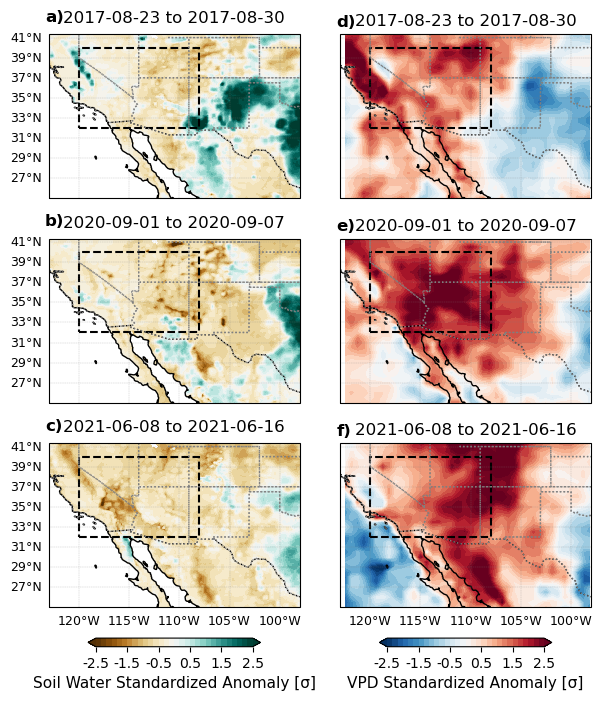

In [22]:
# =========================================================
# Shared settings
# =========================================================
extent = [-123, -98, 25, 41]

titles = [
    "2017-08-23 to 2017-08-30",
    "2020-09-01 to 2020-09-07",
    "2021-06-08 to 2021-06-16"]

sm_labels  = ['a', 'b', 'c']
vpd_labels = ['d', 'e', 'f']

lat_min, lat_max = 32, 40
lon_min, lon_max = -120, -108


vabs_sm = 2.5
vabs_vpd = 2.5

sm_norm = TwoSlopeNorm(vcenter=0, vmin=-vabs_sm, vmax=vabs_sm)
vpd_norm = TwoSlopeNorm(vcenter=0, vmin=-vabs_vpd, vmax=vabs_vpd)

# figure: 3x2 
fig, axes = plt.subplots(3, 2, figsize=(7, 8), subplot_kw={'projection': ccrs.PlateCarree()})

fig.subplots_adjust(wspace=0.16, hspace=0.22)

pcm_sm = None
pcm_vpd = None

for i in range(3):

    # 1) Soil Moisture
    ax_sm = axes[i, 0]

    sm_anom = soil_moist_anomalies[i]
    sm_var = sm_anom['swvl1']

    lon_name_sm = 'longitude' if 'longitude' in sm_var.coords else 'lon'
    lat_name_sm = 'latitude' if 'latitude' in sm_var.coords else 'lat'

    lon2d_sm, lat2d_sm = np.meshgrid( sm_var[lon_name_sm], sm_var[lat_name_sm])

    ax_sm._autoscaleXon = False
    ax_sm._autoscaleYon = False
    ax_sm.set_extent(extent)

    pcm_sm = ax_sm.contourf(lon2d_sm,lat2d_sm,sm_var,cmap='BrBG',
        norm=sm_norm,levels=np.linspace(-vabs_sm, vabs_sm, 31),
        transform=ccrs.PlateCarree(),extend='both')

    ax_sm.add_patch(Rectangle((lon_min, lat_min),lon_max - lon_min,
        lat_max - lat_min,linewidth=1.5,edgecolor='black',facecolor='none',
        linestyle='--',transform=ccrs.PlateCarree() ))

    ax_sm.set_title(titles[i], fontsize=12)

    ax_sm.add_feature(cf.COASTLINE)
    ax_sm.add_feature(cf.BORDERS, linestyle=':')
    ax_sm.add_feature(cf.STATES, linestyle=':', edgecolor='gray')

    # Grid and labels
    gl = ax_sm.gridlines(draw_labels=True,linewidth=0.3,color='gray',
        alpha=0.5,linestyle='--')

    gl.top_labels = False
    gl.right_labels = False

    #longitude labels
    if i < 2:
        gl.bottom_labels = False
    else:
        gl.bottom_labels = True

    # Latitude labels
    gl.left_labels = True

    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    gl.xlocator = mticker.FixedLocator(np.arange(-125, -97, 5))
    gl.ylocator = mticker.FixedLocator(np.round(np.arange(25, 43, 2), 1))

    ax_sm.text(-0.015,1.15,f"{sm_labels[i]})",transform=ax_sm.transAxes,
        fontsize=12,fontweight='bold',va='top',ha='left')


    # 2) VPD
    ax_vpd = axes[i, 1]

    v = vpd_std_weekly_means[i]

    if 'longitude' in v.coords and 'lon' not in v.coords:
        v = v.rename({'longitude': 'lon'})

    if 'latitude' in v.coords and 'lat' not in v.coords:
        v = v.rename({'latitude': 'lat'})

    v = v.squeeze(drop=True)

    lon2d_vpd, lat2d_vpd = np.meshgrid(
        v['lon'],
        v['lat'])

    ax_vpd._autoscaleXon = False
    ax_vpd._autoscaleYon = False
    ax_vpd.set_extent(extent)

    pcm_vpd = ax_vpd.contourf(lon2d_vpd,lat2d_vpd,v,cmap='RdBu_r',
        norm=vpd_norm,levels=np.linspace(-vabs_vpd, vabs_vpd, 31),
        transform=ccrs.PlateCarree(),extend='both')

    ax_vpd.add_patch(Rectangle((lon_min, lat_min),lon_max - lon_min,
        lat_max - lat_min,linewidth=1.5,edgecolor='black',facecolor='none',
        linestyle='--',transform=ccrs.PlateCarree()))

    ax_vpd.set_title(titles[i], fontsize=12)

    ax_vpd.add_feature(cf.COASTLINE)
    ax_vpd.add_feature(cf.BORDERS, linestyle=':')
    ax_vpd.add_feature(cf.STATES, linestyle=':', edgecolor='gray')

    
    # grid and labels
    gl = ax_vpd.gridlines(draw_labels=True,linewidth=0.3,color='gray',
        alpha=0.5,linestyle='--')

    gl.top_labels = False
    gl.right_labels = False

    #  longitude labels 
    if i < 2:
        gl.bottom_labels = False
    else:
        gl.bottom_labels = True

    # latitude labels
    gl.left_labels = False

    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    gl.xlocator = mticker.FixedLocator(np.arange(-125, -97, 5))
    gl.ylocator = mticker.FixedLocator(np.round(np.arange(25, 43, 2), 1))

    ax_vpd.text(-0.015, 1.12,f"{vpd_labels[i]})",transform=ax_vpd.transAxes,fontsize=12,
        fontweight='bold',va='top',ha='left')

# Colorbars
cbar_sm = fig.colorbar(pcm_sm,ax=axes[:, 0].tolist(),orientation='horizontal',
    fraction=0.014,pad=0.05)

ticks_sm = np.arange(-vabs_sm, vabs_sm + 1.0, 1.0)
cbar_sm.set_ticks(ticks_sm)

cbar_sm.set_label('Soil Water Standardized Anomaly [σ]',fontsize=11)

cbar_sm.ax.tick_params(labelsize=10)
cbar_sm.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

cbar_vpd = fig.colorbar(pcm_vpd,ax=axes[:, 1].tolist(),orientation='horizontal',
    fraction=0.014,pad=0.05)

ticks_vpd = np.arange(-vabs_vpd, vabs_vpd + 1.0, 1.0)
cbar_vpd.set_ticks(ticks_vpd)

cbar_vpd.set_label('VPD Standardized Anomaly [σ]',fontsize=11)

cbar_vpd.ax.tick_params(labelsize=10)
cbar_vpd.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.savefig('Figure4_Soil_Water_VPD_Standardized_Anomalies.png', dpi=200, bbox_inches='tight')

plt.show()

In [23]:
# ============================================================
# Domain-mean standardized anomalies
# ============================================================

# 2017 preceding period: August 23–30
sm_2017 = soil_moist_anomalies[0]["swvl1"].sel(latitude=slice(40, 32),longitude=slice(-120, -108))

sm_mean_2017 = float(sm_2017.mean(dim=["latitude", "longitude"], skipna=True).compute().item())


# 2020 preceding period: September 1–7
sm_2020 = soil_moist_anomalies[1]["swvl1"].sel(latitude=slice(40, 32),longitude=slice(-120, -108))

sm_mean_2020 = float(sm_2020.mean(dim=["latitude", "longitude"], skipna=True).compute().item())


# 2021 preceding period: June 8–16
sm_2021 = soil_moist_anomalies[2]["swvl1"].sel(latitude=slice(40, 32),longitude=slice(-120, -108))

sm_mean_2021 = float(sm_2021.mean(dim=["latitude", "longitude"], skipna=True).compute().item())


# Display results
print(f"2017 Southwest mean SM anomaly: {sm_mean_2017:.2f}σ")
print(f"2020 Southwest mean SM anomaly: {sm_mean_2020:.2f}σ")
print(f"2021 Southwest mean SM anomaly: {sm_mean_2021:.2f}σ")

2017 Southwest mean SM anomaly: -0.40σ
2020 Southwest mean SM anomaly: -0.61σ
2021 Southwest mean SM anomaly: -0.76σ


# 4. Figure 5. Energy- and water-limited land-atmosphere coupling regimes

This section uses hot pixels from Figure 3 (`TS_z > 1σ`) across the domain. For each hot pixel, temporal Spearman correlations are calculated over the combined period from the preceding week and the AEE duration.

The phase diagram uses `R(SM_anom, LHF_anom)` on the x-axis and `R(TMAX_anom, LHF_anom)` on the y-axis. Regimes I-II are energy-limited, Regimes III-V are transition, and Regimes VI-VII are water-limited. Each pixel/dot is colored by its event-mean standardized AOD anomaly.

Latent heat flux is converted to upward-positive W m⁻² when the source is an accumulated energy flux, so positive values indicate stronger upward latent heat transfer.


### AOD from MERRA-2

In [24]:
#====Directory====
dirme_aod = '/xdisk/sylvia/julianamejia/tmp_merra_aod'

In [25]:
#====Reading files====
ds_aod_merra = []
file_names = []
errors = []


for archivo in os.listdir(dirme_aod):
    if archivo.endswith('.nc4'):
        file_path = os.path.join(dirme_aod, archivo)
        try:
            dsme_aod = xr.open_dataset(file_path, engine="netcdf4")
            ds_aod_merra.append(dsme_aod)
            file_names.append(archivo)
        except FileNotFoundError:
            errors.append(archivo)

In [26]:
#====Concat files by time====
aod_merra = xr.concat(ds_aod_merra, dim='time', coords='minimal')
aod_merra = aod_merra.set_index(time='time')
aod_merra = aod_merra.sortby('time')

In [27]:
#====Resample AOD to daily mean====
daily_mean_aod_merra = aod_merra[['TOTEXTTAU', 'BCEXTTAU', 'DUEXTTAU','OCEXTTAU']].groupby(aod_merra['time'].dt.floor('D')).mean('time')

# Rename the new dimension to time
daily_mean_aod_merra = daily_mean_aod_merra.rename({'floor': 'time'})

# Assign result to another variable
mean_aod_merra = daily_mean_aod_merra

In [28]:
event_names = ["Sep 2017", "Sep 2020", "Jun 2021"]

In [29]:
# ---------------------------------------------------------
# From figures 3 and 4
# ---------------------------------------------------------


# Full AEE windows for the coupling analysis
aee_windows = {
    "Sep 2017": ("2017-08-23", "2017-09-09"),
    "Sep 2020": ("2020-09-01", "2020-09-22"),
    "Jun 2021": ("2021-06-08", "2021-06-24"),}

# AEE events duration used for the dot colors (event-mean AOD anomaly).
aee_event_windows = {
    "Sep 2017": ("2017-09-01", "2017-09-09"),
    "Sep 2020": ("2020-09-08", "2020-09-22"),
    "Jun 2021": ("2021-06-17", "2021-06-24"),}

# Figure 3 full study region
extent_fig3 = [-123, -98, 25, 41] 

# Spearman correlation threshold for Phase Diagram
r_thr = 0.5

EPS = 1e-9


def standardize_latlon_names(da):
    """
    Rename latitude/longitude coordinates to lat/lon if needed.
    """
    rename_dict = {}

    if "latitude" in da.coords and "lat" not in da.coords:
        rename_dict["latitude"] = "lat"

    if "longitude" in da.coords and "lon" not in da.coords:
        rename_dict["longitude"] = "lon"

    if rename_dict:
        da = da.rename(rename_dict)

    return da


def subset_fig3_domain(da, extent=extent_fig3):
    """
    Subset any lat/lon DataArray to the Figure 3 domain.
    """
    da = standardize_latlon_names(da)

    lon_min, lon_max, lat_min, lat_max = extent

    if da["lat"][0] < da["lat"][-1]:
        da = da.sel(lat=slice(lat_min, lat_max))
    else:
        da = da.sel(lat=slice(lat_max, lat_min))

    da = da.sel(lon=slice(lon_min, lon_max))

    return da


def spearman_1d(x, y):
    """
    Spearman correlation for one pixel through time.
    """
    good = np.isfinite(x) & np.isfinite(y)

    if good.sum() < 4:
        return np.nan

    r, p = spearmanr(x[good], y[good])

    return r


In [30]:
# =========================================================
# Read ERA5-Land latent heat flux
# =========================================================

lhf_dir = "/xdisk/sylvia/julianamejia/era5land_data"

lhf_files = sorted([
    os.path.join(lhf_dir, f)
    for f in os.listdir(lhf_dir)
    if f.endswith(".nc")
    and (
        "slhf" in f.lower()
        or "latent" in f.lower()
        or "lhf" in f.lower()
    )
])

print(f"Found {len(lhf_files)} candidate LHF files")

for f in lhf_files[:10]:
    print(os.path.basename(f))

if len(lhf_files) == 0:
    raise FileNotFoundError(
        "No files were found")

# Open files
lhf_ds = xr.open_mfdataset(
    lhf_files,
    combine="by_coords")

#print(lhf_ds)

Found 264 candidate LHF files
era5land_slhf_2003_01.nc
era5land_slhf_2003_02.nc
era5land_slhf_2003_03.nc
era5land_slhf_2003_04.nc
era5land_slhf_2003_05.nc
era5land_slhf_2003_06.nc
era5land_slhf_2003_07.nc
era5land_slhf_2003_08.nc
era5land_slhf_2003_09.nc
era5land_slhf_2003_10.nc
<xarray.Dataset>
Dimensions:     (valid_time: 192864, latitude: 221, longitude: 251)
Coordinates:
    number      int64 0
  * valid_time  (valid_time) datetime64[ns] 2003-01-01 ... 2024-12-31T23:00:00
  * latitude    (latitude) float64 47.0 46.9 46.8 46.7 ... 25.3 25.2 25.1 25.0
  * longitude   (longitude) float64 -123.0 -122.9 -122.8 ... -98.2 -98.1 -98.0
    expver      (valid_time) object dask.array<chunksize=(744,), meta=np.ndarray>
Data variables:
    slhf        (valid_time, latitude, longitude) float32 dask.array<chunksize=(744, 221, 251), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:     

In [31]:
# =========================================================
# Extract latent heat flux variable
# =========================================================

LHF_raw = lhf_ds['slhf']
LHF_raw = standardize_latlon_names(LHF_raw)

# Standardize time coordinate name
if "valid_time" in LHF_raw.coords and "time" not in LHF_raw.coords:
    LHF_raw = LHF_raw.rename({"valid_time": "time"})

# Remove extra dimensions if present
LHF_raw = LHF_raw.squeeze(drop=True)

# Sort coordinates
LHF_raw = LHF_raw.sortby("time")
LHF_raw = subset_fig3_domain(LHF_raw)

# ---------------------------------------------------------
# ERA5/ERA5-Land latent heat flux is negative for upward transfer.
# We convert slhf from J m-2 to W m-2 by dividing by 3600
# ---------------------------------------------------------

LHF = -LHF_raw/ 3600
    

LHF.name = "LHF_upward_positive_Wm2"
LHF.attrs["long_name"] = "Latent heat flux, positive upward"
LHF.attrs["units"] = "W m-2"
LHF.attrs["note"] = ('Hourly ERA-5 Land surface latent heat flux is converted from J m-2 to W m-2 by dividing by 3600 and multiplying by -1 for positive upward transfer')

print(LHF)


<xarray.DataArray 'LHF_upward_positive_Wm2' (time: 192864, lat: 161, lon: 251)>
dask.array<truediv, shape=(192864, 161, 251), dtype=float32, chunksize=(744, 161, 251), chunktype=numpy.ndarray>
Coordinates:
    number   int64 0
  * time     (time) datetime64[ns] 2003-01-01 ... 2024-12-31T23:00:00
  * lat      (lat) float64 41.0 40.9 40.8 40.7 40.6 ... 25.4 25.3 25.2 25.1 25.0
  * lon      (lon) float64 -123.0 -122.9 -122.8 -122.7 ... -98.2 -98.1 -98.0
    expver   (time) object dask.array<chunksize=(744,), meta=np.ndarray>
Attributes:
    long_name:  Latent heat flux, positive upward
    units:      W m-2
    note:       Hourly ERA-5 Land surface latent heat flux is converted from ...


In [48]:
# ============================================================
# Daily datasets
# ============================================================


# Temperature from Figure 3 (already daily maximum)
TS_daily = max_data["TS_max"]
TS_daily = subset_fig3_domain(TS_daily)
TS_daily = TS_daily.sortby("time")

# Soil moisture from Figure 4
SM_daily = soil_water["swvl1"]

# Standardize the time coordinate name
if "valid_time" in SM_daily.coords and "time" not in SM_daily.coords:
    SM_daily = SM_daily.rename({"valid_time": "time"})

# Standardize spatial coordinate names
SM_daily = standardize_latlon_names(SM_daily)

# Remove dimensions of length one, if present
SM_daily = SM_daily.squeeze(drop=True)

# Make sure time uses datetime64
SM_daily["time"] = pd.to_datetime(SM_daily["time"].values)

# Select the Figure 3 study domain
SM_daily = subset_fig3_domain(SM_daily)
SM_daily = SM_daily.sortby("time")

print("SM_daily:", SM_daily)

# Latent heat flux
LHF_daily = LHF.copy()
LHF_daily["time"] = pd.to_datetime(LHF_daily["time"].values)
LHF_daily = LHF_daily.sortby("time")

LHF_daily = (LHF_daily.groupby(LHF_daily["time"].dt.floor("D")).max(dim="time", skipna=True).rename({"floor": "time"}))
LHF_daily["time"] = pd.to_datetime(LHF_daily["time"].values)
LHF_daily = subset_fig3_domain(LHF_daily)
LHF_daily = LHF_daily.sortby("time")

# AOD from MERRA-2 (meam_aod_merra is already daily)
AOD_daily = mean_aod_merra["TOTEXTTAU"]
AOD_daily = subset_fig3_domain(AOD_daily)
AOD_daily = AOD_daily.sortby("time")

#print("TS_daily:", TS_daily)
#print("SM_daily:", SM_daily)
#print("LHF_daily:", LHF_daily)
#print("AOD_daily:", AOD_daily)


SM_daily: <xarray.DataArray 'swvl1' (time: 8401, lat: 161, lon: 251)>
array([[[0.51878357, 0.5199585 , 0.5189209 , ..., 0.27583313,
         0.2851715 , 0.28684998],
        [0.5197296 , 0.517395  , 0.51937866, ..., 0.2819214 ,
         0.28424072, 0.2862854 ],
        [0.5198517 , 0.5172882 , 0.5089569 , ..., 0.28425598,
         0.2856598 , 0.28804016],
        ...,
        [       nan,        nan,        nan, ..., 0.2040863 ,
         0.20559692, 0.20443726],
        [       nan,        nan,        nan, ..., 0.19841003,
         0.19593811, 0.1867981 ],
        [       nan,        nan,        nan, ..., 0.19548035,
         0.18421936, 0.14544678]],

       [[0.519989  , 0.5122833 , 0.5152893 , ..., 0.27511597,
         0.28437805, 0.28605652],
        [0.5165558 , 0.519989  , 0.5200043 , ..., 0.28105164,
         0.28337097, 0.28544617],
        [0.5190277 , 0.5114746 , 0.50338745, ..., 0.28330994,
         0.28474426, 0.28712463],
...
        [       nan,        nan,        nan, ..

In [41]:
# =========================================================
# daily standardized anomalies
# =========================================================

def event_daily_standardized_anomalies(da, start_str, end_str):
    """
    For a given event window, calculate daily standardized anomalies.

    For each event day, the climatology is based on the same month-day
    from all available years except the event year.
    """
    da = da.sortby("time")

    start_dt = pd.to_datetime(start_str)
    end_dt   = pd.to_datetime(end_str)
    event_year = start_dt.year

    event_days = pd.date_range(start_dt, end_dt, freq="D")

    z_list = []

    for day in event_days:

        mmdd = day.strftime("%m-%d")

        # Event day value
        if day.to_datetime64() not in da["time"].values:
            raise KeyError(f"Missing daily value for {day.date()} in {da.name or 'input DataArray'}")
        event_value = da.sel(time=day)

        # Same calendar day in all other years
        clim_days = da.where(
            (da["time"].dt.strftime("%m-%d") == mmdd)
            & (da["time"].dt.year != event_year),
            drop=True)

        clim_mean = clim_days.mean("time", skipna=True)
        clim_std  = clim_days.std("time", skipna=True, ddof=1)
        clim_std  = xr.where(clim_std < EPS, np.nan, clim_std)

        z = (event_value - clim_mean) / clim_std
        z = z.expand_dims(time=[day])

        z_list.append(z)

    z_event = xr.concat(z_list, dim="time")
    z_event = z_event.sortby("time")

    return z_event


In [42]:
# =========================================================
# Build daily anomaly fields for each AEE
# =========================================================

TS_z_event = {}
SM_z_event = {}
LHF_z_event = {}
AOD_z_event = {}
AOD_z_event_mean = {}
hot_masks_event = {}

for event_name, (start, end) in aee_windows.items():

    print(f"Processing {event_name}: {start} to {end}")

    # Daily standardized anomalies
    ts_z = event_daily_standardized_anomalies(TS_daily, start, end)
    sm_z = event_daily_standardized_anomalies(SM_daily, start, end)
    lhf_z = event_daily_standardized_anomalies(LHF_daily, start, end)
    aod_z = event_daily_standardized_anomalies(AOD_daily, start, end)

    # Put SM, LHF, and AOD on the temperature grid
    sm_z = sm_z.interp(lat=ts_z["lat"],lon=ts_z["lon"],method="nearest")

    lhf_z = lhf_z.interp(lat=ts_z["lat"],lon=ts_z["lon"],method="nearest")

    aod_z = aod_z.interp(lat=ts_z["lat"],lon=ts_z["lon"], method="nearest")

    # Hot pixels from Figure 3 criterion:
    # event-mean TS_z > 1 std
    ts_z_mean = ts_z.mean("time", skipna=True)
    hot_mask = ts_z_mean > 1

    # AEE-only mean standardized AOD anomaly for dot color.
    aod_start, aod_end = aee_event_windows[event_name]
    aod_z_mean = aod_z.sel(time=slice(aod_start, aod_end)).mean("time", skipna=True)

    TS_z_event[event_name] = ts_z
    SM_z_event[event_name] = sm_z
    LHF_z_event[event_name] = lhf_z
    AOD_z_event[event_name] = aod_z
    AOD_z_event_mean[event_name] = aod_z_mean
    hot_masks_event[event_name] = hot_mask


Processing Sep 2017: 2017-08-23 to 2017-09-09
Processing Sep 2020: 2020-09-01 to 2020-09-22
Processing Jun 2021: 2021-06-08 to 2021-06-24
Done.


In [43]:
# =========================================================
# Number of "hot" pixels vs scaterplot pixels
# =========================================================

diagnostic_rows = []

for i, event_name in enumerate(event_names):

    print(f"\n--- {event_name} ---")

    # Original Figure 3 hot mask
    hot_fig3 = figure3_results[i][4]
    hot_fig3 = subset_fig3_domain(hot_fig3)

    # Variables used for correlations
    ts_z = TS_z_event[event_name]
    sm_z = SM_z_event[event_name]
    lhf_z = LHF_z_event[event_name]
    aod_z_mean = AOD_z_event_mean[event_name]

    # Put Figure 3 hot mask on the current TS grid
    hot_on_ts = hot_fig3.astype(float).interp(lat=ts_z["lat"],lon=ts_z["lon"],method="nearest")

    hot_on_ts = hot_on_ts > 0.5

    # Check variable availability through time
    ts_finite  = np.isfinite(ts_z).sum("time") >= 4
    sm_finite  = np.isfinite(sm_z).sum("time") >= 4
    lhf_finite = np.isfinite(lhf_z).sum("time") >= 4
    aod_finite = np.isfinite(aod_z_mean)

    n_fig3_hot = int(hot_on_ts.sum().compute().item())
    n_ts_valid = int((hot_on_ts & ts_finite).sum().compute().item())
    n_sm_valid = int((hot_on_ts & sm_finite).sum().compute().item())
    n_lhf_valid = int((hot_on_ts & lhf_finite).sum().compute().item())
    n_aod_valid = int((hot_on_ts & aod_finite).sum().compute().item())

    n_all_valid = int((
        hot_on_ts
        & ts_finite
        & sm_finite
        & lhf_finite
        & aod_finite).sum().compute().item())

    diagnostic_rows.append({
        "Event": event_name,
        "Figure 3 hot pixels": n_fig3_hot,
        "Hot pixels with TS >=4 days": n_ts_valid,
        "Hot pixels with SM >=4 days": n_sm_valid,
        "Hot pixels with LHF >=4 days": n_lhf_valid,
        "Hot pixels with AOD color": n_aod_valid,
        "Final scatter pixels": n_all_valid,})

diagnostic_df = pd.DataFrame(diagnostic_rows)
diagnostic_df



--- Sep 2017 ---


/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)



--- Sep 2020 ---


/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)



--- Jun 2021 ---


/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


,Event,Figure 3 hot pixels,Hot pixels with TS >=4 days,Hot pixels with SM >=4 days,Hot pixels with LHF >=4 days,Hot pixels with AOD color,Final scatter pixels
0,Sep 2017,344,344,298,299,344,298
1,Sep 2020,645,645,557,558,645,557
2,Jun 2021,549,549,493,493,549,493


In [44]:
# =========================================================
# Phase- Diagram with spearman correlations over Figure 3 hot pixels only
#
# x-axis: R(SM_anom, LHF_anom)
# y-axis: R(TMAX_anom, LHF_anom)
# color: mean standardized AOD anomaly
#
# IMPORTANT:
# Hot pixels are taken from Figure 3:
# figure3_results[i][4] = TS_z > 1 mask
# =========================================================

coupling_points = {}
summary_rows = []

for i, event_name in enumerate(event_names):

    print(f"Calculating correlations for {event_name}")

    # Daily anomalies for the event
    ts_z = TS_z_event[event_name].chunk({"time": -1})
    sm_z = SM_z_event[event_name].chunk({"time": -1})
    lhf_z = LHF_z_event[event_name].chunk({"time": -1})

    aod_z_mean = AOD_z_event_mean[event_name]

    # Use the original Figure 3 hot mask
    hot_fig3 = figure3_results[i][4]
    hot_fig3 = subset_fig3_domain(hot_fig3)

    hot_mask = hot_fig3.astype(float).interp(lat=ts_z["lat"],lon=ts_z["lon"],method="nearest")

    hot_mask = hot_mask > 0.5

    # Spearman correlations through time for each pixel
    r_sm_lhf = xr.apply_ufunc(spearman_1d,sm_z,lhf_z,input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],vectorize=True,dask="parallelized",output_dtypes=[float],)

    r_ts_lhf = xr.apply_ufunc(spearman_1d,ts_z,lhf_z,input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],vectorize=True,dask="parallelized",output_dtypes=[float],)

    # Computing arrays before flattening
    r_sm_lhf = r_sm_lhf.compute()
    r_ts_lhf = r_ts_lhf.compute()
    aod_z_mean = aod_z_mean.compute()
    hot_mask = hot_mask.compute()

    # Keep only Figure 3 hot pixels with valid correlations
    valid = (
        hot_mask
        & np.isfinite(r_sm_lhf)
        & np.isfinite(r_ts_lhf)
        & np.isfinite(aod_z_mean))

    x = r_sm_lhf.where(valid).values.ravel()
    y = r_ts_lhf.where(valid).values.ravel()
    c = aod_z_mean.where(valid).values.ravel()

    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)

    x = x[good]
    y = y[good]
    c = c[good]

    df_evt = pd.DataFrame({ "Event": event_name,"r_SM_LHF": x, "r_TMAX_LHF": y, "AOD_z": c,})

    print(event_name, "| Figure 3 hot pixels:",int(hot_mask.sum().item()), "| Scatter pixels:",len(df_evt) )

    
    # Regime classification in phase diagram space
    df_evt["Regime"] = "Weak / mixed coupling"

    df_evt.loc[
        (df_evt["r_SM_LHF"] >= r_thr) & (df_evt["r_TMAX_LHF"] <= -r_thr),
        "Regime"] = "Water-limited"

    df_evt.loc[
        (df_evt["r_SM_LHF"] <= -r_thr) & (df_evt["r_TMAX_LHF"] >= r_thr),
        "Regime"] = "Energy-limited"

    df_evt.loc[
        (df_evt["r_SM_LHF"] >= r_thr) & (df_evt["r_TMAX_LHF"] >= r_thr),
        "Regime"] = "Moisture-enhanced evaporation"

    df_evt.loc[
        (df_evt["r_SM_LHF"] <= -r_thr) & (df_evt["r_TMAX_LHF"] <= -r_thr),
        "Regime"] = "Suppressed evaporation"

    coupling_points[event_name] = df_evt

    # Summary table 
    n_total = len(df_evt)

    for regime_name in [
        "Water-limited",
        "Energy-limited",
        "Moisture-enhanced evaporation",
        "Suppressed evaporation",
        "Weak / mixed coupling",
    ]:

        sub = df_evt[df_evt["Regime"] == regime_name]

        summary_rows.append({
            "Event": event_name,
            "Regime": regime_name,
            "Pixels": len(sub),
            "Percent of hot pixels": 100 * len(sub) / n_total if n_total > 0 else np.nan,
            "Total scatter pixels": n_total,
            "Mean AOD_z": sub["AOD_z"].mean() if len(sub) > 0 else np.nan,
            "Mean r_SM_LHF": sub["r_SM_LHF"].mean() if len(sub) > 0 else np.nan,
            "Mean r_TMAX_LHF": sub["r_TMAX_LHF"].mean() if len(sub) > 0 else np.nan,})

coupling_summary_df = pd.DataFrame(summary_rows)

coupling_summary_df


Calculating correlations for Sep 2017


/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Sep 2017 | Figure 3 hot pixels: 344 | Scatter pixels: 298
Calculating correlations for Sep 2020


/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Sep 2020 | Figure 3 hot pixels: 645 | Scatter pixels: 557
Calculating correlations for Jun 2021


/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/u32/julianamejia/.local/lib/python3.8/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Jun 2021 | Figure 3 hot pixels: 549 | Scatter pixels: 493


,Event,Regime,Pixels,Percent of hot pixels,Total scatter pixels,Mean AOD_z,Mean r_SM_LHF,Mean r_TMAX_LHF
0,Sep 2017,Water-limited,55,18.456376,298,1.157777,0.725265,-0.624205
1,Sep 2017,Energy-limited,1,0.335570,298,2.130279,-0.589267,0.832817
2,Sep 2017,Moisture-enhanced evaporation,1,0.335570,298,1.433837,0.711042,0.564499
3,Sep 2017,Suppressed evaporation,0,0.000000,298,NaN,NaN,NaN
4,Sep 2017,Weak / mixed coupling,241,80.872483,298,1.622291,0.468383,-0.156353
5,Sep 2020,Water-limited,96,17.235189,557,6.923645,0.775409,-0.618165
6,Sep 2020,Energy-limited,3,0.538600,557,8.314187,-0.573875,0.561077
7,Sep 2020,Moisture-enhanced evaporation,4,0.718133,557,6.228800,0.797854,0.620836
8,Sep 2020,Suppressed evaporation,0,0.000000,557,NaN,NaN,NaN
9,Sep 2020,Weak / mixed coupling,454,81.508079,557,7.416900,0.432614,0.004092


In [45]:
# =========================================================
# Phase Diagram plot setup
# =========================================================

def assign_seven_regimes(df_evt, r_thr=0.5):
    """
    Assigning regimes I-VII 

    x = r_SM_LHF
    y = r_TMAX_LHF
    """

    df = df_evt.copy()

    x = df["r_SM_LHF"].values
    y = df["r_TMAX_LHF"].values

    regime_num = np.full(len(df), np.nan)
    regime_group = np.array(["Outside seven regimes"] * len(df), dtype=object)

    # I
    m1 = (x < -r_thr) & (y > r_thr)
    regime_num[m1] = 1
    regime_group[m1] = "Energy-limited"

    # II
    m2 = (x >= -r_thr) & (x < 0) & (y > r_thr)
    regime_num[m2] = 2
    regime_group[m2] = "Energy-limited"

    # III
    m3 = (x >= -r_thr) & (x < 0) & (y > 0) & (y <= r_thr)
    regime_num[m3] = 3
    regime_group[m3] = "Transitioning"

    # IV
    m4 = (x >= 0) & (x < r_thr) & (y > 0) & (y <= r_thr)
    regime_num[m4] = 4
    regime_group[m4] = "Transitioning"

    # V
    m5 = (x >= 0) & (x < r_thr) & (y > -r_thr) & (y <= 0)
    regime_num[m5] = 5
    regime_group[m5] = "Transitioning"

    # VI
    m6 = (x >= r_thr) & (x <= 1) & (y > -r_thr) & (y <= 0)
    regime_num[m6] = 6
    regime_group[m6] = "Water-limited"

    # VII
    m7 = (x >= r_thr) & (y <= -r_thr)
    regime_num[m7] = 7
    regime_group[m7] = "Water-limited"

    df["Regime_num"] = regime_num
    df["Regime_group"] = regime_group

    return df


def compute_seven_regime_percentages(df_evt, r_thr=0.5):
    """
    Compute percentages for regimes I-VII.
    Percentages are relative to all plotted dots in the panel.
    """

    df = assign_seven_regimes(df_evt, r_thr=r_thr)
    total = len(df)

    pct_regime = {}
    for reg in range(1, 8):
        pct_regime[reg] = 100 * np.sum(df["Regime_num"] == reg) / total if total > 0 else np.nan

    pct_group = {}
    for group in ["Energy-limited", "Transitioning", "Water-limited", "Outside seven regimes"]:
        pct_group[group] = 100 * np.sum(df["Regime_group"] == group) / total if total > 0 else np.nan

    return pct_regime, pct_group, df


def draw_seven_regime_boxes(ax, r_thr=0.5):


    # (x0, y0, width, height, label, facecolor)
    boxes = [
        (-1.0,   r_thr, 0.5, 0.5, "I",   "aliceblue"),
        (-0.5,   r_thr, 0.5, 0.5, "II",  "aliceblue"),
        (-0.5,   0.0,   0.5, 0.5, "III", "whitesmoke"),
        ( 0.0,   0.0,   0.5, 0.5, "IV",  "whitesmoke"),
        ( 0.0,  -0.5,   0.5, 0.5, "V",   "whitesmoke"),
        ( 0.5,  -0.5,   0.5, 0.5, "VI",  "mistyrose"),
        ( 0.5,  -1.0,   0.5, 0.5, "VII", "mistyrose"), ]

    for x0, y0, w, h, label, fc in boxes:
        rect = Rectangle((x0, y0), w, h,facecolor=fc,edgecolor="0.3",
            linewidth=1.0,alpha=0.40,zorder=0)
        ax.add_patch(rect)

        # Roman numeral 
        ax.text(x0 + 0.03,y0 + h - 0.07,label,fontsize=12,fontweight="bold",color="0.25",
            ha="left",va="top",zorder=2)

    # axes and thresholds
    ax.axhline(0, color="0.4", lw=1.0, ls="--", dashes=(4, 4), zorder=1)
    ax.axvline(0, color="0.4", lw=1.0, ls="--", dashes=(4, 4), zorder=1)

    ax.axhline(r_thr, color="0.25", lw=1.0, zorder=1)
    ax.axhline(-r_thr, color="0.25", lw=1.0, zorder=1)
    ax.axvline(-r_thr, color="0.25", lw=1.0, zorder=1)
    ax.axvline(0, color="0.25", lw=1.0, zorder=1)
    ax.axvline(r_thr, color="0.25", lw=1.0, zorder=1)


def add_regime_box_percentages(ax, pct_regime):
    """
    Add the regime percentages inside the seven boxes.
    """

    txt_kw = dict(fontsize=12,color="black", ha="left",va="bottom",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.65),zorder=4)

    # Position each percentage inside its regime box
    positions = {
        1: (-0.96,  0.52),
        2: (-0.46,  0.52),
        3: (-0.46,  0.02),
        4: ( 0.04,  0.02),
        5: ( 0.04, -0.48),
        6: ( 0.54, -0.48),
        7: ( 0.54, -0.98),}

    for reg, (x, y) in positions.items():
        ax.text(x, y, f"{pct_regime[reg]:.2f}%", **txt_kw)


def add_group_percentages(ax, pct_group):
    """
    Add grouped percentages for Energy-limited, Transitioning, Water-limited.
    """

    txt_kw = dict(fontsize=12,ha="center",va="center",
                  bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.5", alpha=0.80),zorder=5 )

    ax.text(-0.78, 0.80,f"Energy-limited\n{pct_group['Energy-limited']:.2f}%",**txt_kw)

    ax.text(0.23, 0.18,f"Transitioning\n{pct_group['Transitioning']:.2f}%",**txt_kw)

    ax.text(0.76, -0.72, f"Water-limited\n{pct_group['Water-limited']:.2f}%",**txt_kw)

In [46]:
def plot_phase_panel_seven_regimes(ax, df_evt, event_name, panel_label, r_thr, fig):

    df_evt = df_evt.copy()

    vmax = np.nanmax(np.abs(df_evt["AOD_z"]))

    if np.isnan(vmax) or np.isclose(vmax, 0):
        vmax = 1.0

    norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)

    pct_regime, pct_group, df_evt = compute_seven_regime_percentages(df_evt,r_thr=r_thr)

    # Boxes first
    draw_seven_regime_boxes(ax, r_thr=r_thr)

    # Scatter
    sc = ax.scatter(df_evt["r_SM_LHF"],df_evt["r_TMAX_LHF"],c=df_evt["AOD_z"],
        cmap="RdBu_r",norm=norm,s=35,edgecolor="k",linewidth=0.35,alpha=0.88,zorder=3)

    # Add percentages
    add_regime_box_percentages(ax, pct_regime)

    ax.text(-0.96, -0.82,f"Outside\n{pct_group['Outside seven regimes']:.2f}%",fontsize=9,ha="left",
        va="center",color="0.2",bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="none",alpha=0.7),zorder=5)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(f"{panel_label} {event_name}",loc="left",fontsize=14,fontweight="bold")

    ax.tick_params(labelsize=12)

    cbar = fig.colorbar(sc,ax=ax,orientation="vertical",fraction=0.040,pad=0.030)

    cbar.set_label("Mean standardized AOD anomaly",fontsize=11)

    cbar.ax.tick_params(labelsize=8)

    return sc


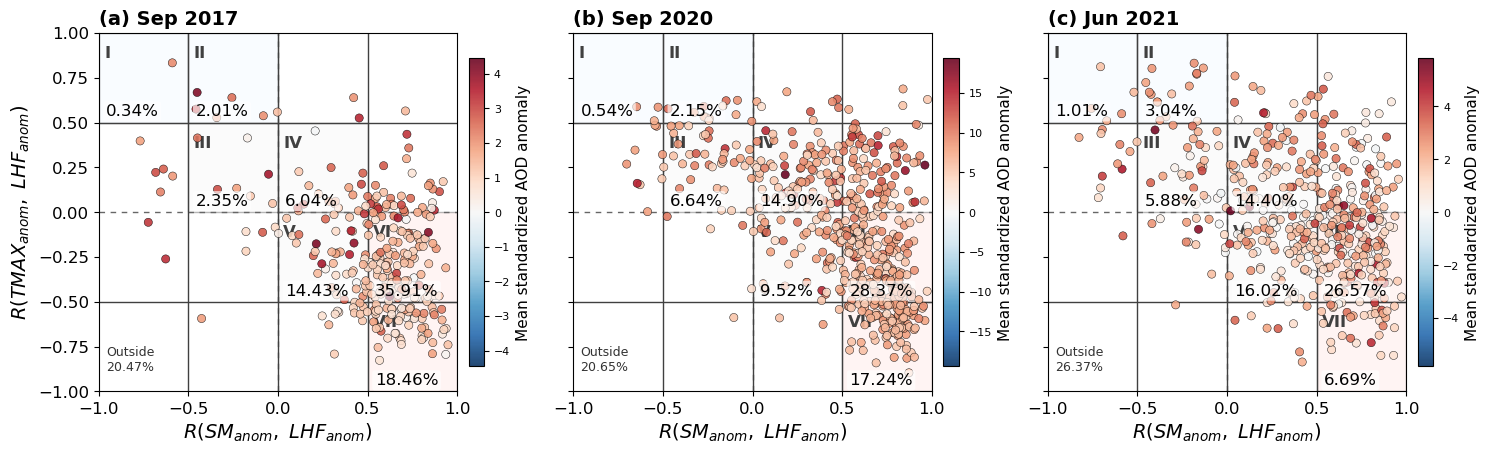

In [47]:
# =========================================================
# Figure 5: Spearman correlation phase space
# =========================================================

panel_order  = ["Sep 2017", "Sep 2020", "Jun 2021"]
panel_labels = ["(a)", "(b)", "(c)"]

fig, axes = plt.subplots( 1, 3,figsize=(15, 4.8),sharex=True, sharey=True)

axes = axes.ravel()

for ax, event_name, panel_label in zip(axes, panel_order, panel_labels):

    df_evt = coupling_points[event_name].copy()

    plot_phase_panel_seven_regimes(ax=ax,df_evt=df_evt, event_name=event_name,
        panel_label=panel_label,r_thr=r_thr,fig=fig)

# Axis labels
axes[0].set_ylabel(r"$R(TMAX_{anom},\ LHF_{anom})$",fontsize=14)

for ax in axes:
    ax.set_xlabel(r"$R(SM_{anom},\ LHF_{anom})$",fontsize=14)

plt.tight_layout()

plt.savefig("Figure5_Land_Atmospheric_Coupling_Regimes.png",dpi=300, bbox_inches="tight")

plt.show()